**MAESTRÍA EN INTELIGENCIA ARTIFICIAL APLICADA**

**Curso: TC5053 - Ciencia y analítica de datos**

Tecnológico de Monterrey

Prof Grettel Barceló Alonso

**Semana 9**
Regresión Logística

---

*   NOMBRE: ---------------------------------------------------------
*   MATRÍCULA: ----------------------------------------------------

En esta actividad trabajarás con el archivo `breast_cancer.csv`, basado en un conjunto de datos sobre características de tumores mamarios, disponible en el repositorio UCI Machine Learning.

Los datos fueron recopilados para analizar si un tumor es maligno (M) o benigno (B) a partir de medidas extraídas de imágenes de biopsias. Las variables incluidas describen propiedades morfológicas y de textura del tumor y se presentan en tres tipos de medida para cada característica:

* `_mean`: valor promedio de la característica en el tumor
* `_se`: error estándar de la característica (variabilidad de la medición)
* `_worst`: peor valor observado de la característica en el tumor

Los indicadores incluidos son:
* `radius_mean` / `radius_se` / `radius_worst`:	Radio del tumor
* `texture_mean` / `texture_se` / `texture_worst`:	Textura del tumor (desviación estándar de intensidad)
* `perimeter_mean` / `perimeter_se` / `perimeter_worst`:	Perímetro del tumor
* `area_mean` / `area_se` / `area_worst`:	Área del tumor
* `smoothness_mean` / `smoothness_se` / `smoothness_worst`:	Suavidad (irregularidad del borde)
* `compactness_mean` / `compactness_se` / `compactness_worst`:	Compacidad (perimeter^2 / area - 1)
* `concavity_mean` / `concavity_se` / `concavity_worst`:	Concavidad de los contornos
* `concave points_mean` / `concave points_se` / `concave points_worst`:	Número de puntos cóncavos en el contorno
* `symmetry_mean` / `symmetry_se` / `symmetry_worst`:	Simetría del tumor
* `fractal_dimension_mean` / `fractal_dimension_se` / `fractal_dimension_worst`:	Dimensión fractal del contorno (complejidad)
* `diagnosis`: Indica si el tumor es benigno (B) o maligno (M). Es la variable de salida o *target*

In [1]:
# Importar las bibliotecas necesarias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import PowerTransformer
from sklearn.decomposition import PCA
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, precision_score, recall_score, accuracy_score
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, roc_auc_score

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


1. Descarga el archivo: `breast_cancer.csv` y guarda, en un dataframe (`cancer_df`), todos sus registros.
* Haz que la columna `id` sea el nuevo índice.
* Utiliza el método `info()` del dataframe, para obtener el resumen de los tipos de datos. ¿Cuántas columnas son numéricas y cuántas de texto?
* Verifica si alguna columna contiene valores faltantes.
* Si existen registros duplicados, elimínalos del dataframe y reinicia el índice para que se mantenga consecutivo.
* Obtén las estadísticas descriptivas, separando las variables numéricas (con asimetría y curtosis) y las categóricas.

In [3]:
ruta_archivo = "/content/drive/MyDrive/Colab Notebooks/Maestria en IA/Ciencia de datos enero 2026/breast_cancer.csv"
cancer_df = pd.read_csv(ruta_archivo)

In [4]:
cancer_df

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [5]:
cancer_df.set_index('id', inplace=True)

# Resumen de tipos de datos
print(cancer_df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 569 entries, 842302 to 92751
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   diagnosis                569 non-null    object 
 1   radius_mean              569 non-null    float64
 2   texture_mean             569 non-null    float64
 3   perimeter_mean           569 non-null    float64
 4   area_mean                569 non-null    float64
 5   smoothness_mean          569 non-null    float64
 6   compactness_mean         569 non-null    float64
 7   concavity_mean           569 non-null    float64
 8   concave points_mean      569 non-null    float64
 9   symmetry_mean            569 non-null    float64
 10  fractal_dimension_mean   569 non-null    float64
 11  radius_se                569 non-null    float64
 12  texture_se               569 non-null    float64
 13  perimeter_se             569 non-null    float64
 14  area_se                 

In [6]:
# Verificar nulos
print(f"Valores faltantes:\n{cancer_df.isnull().sum().sum()}")

# Eliminar duplicados y reiniciar índice
if cancer_df.duplicated().any():
    cancer_df.drop_duplicates(inplace=True)
    cancer_df = cancer_df.reset_index()
    cancer_df.set_index('id', inplace=True)


Valores faltantes:
0


In [7]:
# Estadísticas descriptivas (Numéricas con asimetría y curtosis)
num_stats = cancer_df.select_dtypes(include=[np.number]).describe().T
num_stats['asimetria'] = cancer_df.select_dtypes(include=[np.number]).skew()
num_stats['curtosis'] = cancer_df.select_dtypes(include=[np.number]).kurtosis()
print(num_stats)

# Estadísticas categóricas
print(cancer_df['diagnosis'].value_counts())


                         count        mean         std         min  \
radius_mean              569.0   14.127292    3.524049    6.981000   
texture_mean             569.0   19.289649    4.301036    9.710000   
perimeter_mean           569.0   91.969033   24.298981   43.790000   
area_mean                569.0  654.889104  351.914129  143.500000   
smoothness_mean          569.0    0.096360    0.014064    0.052630   
compactness_mean         569.0    0.104341    0.052813    0.019380   
concavity_mean           569.0    0.088799    0.079720    0.000000   
concave points_mean      569.0    0.048919    0.038803    0.000000   
symmetry_mean            569.0    0.181162    0.027414    0.106000   
fractal_dimension_mean   569.0    0.062798    0.007060    0.049960   
radius_se                569.0    0.405172    0.277313    0.111500   
texture_se               569.0    1.216853    0.551648    0.360200   
perimeter_se             569.0    2.866059    2.021855    0.757000   
area_se             

2. Explora relaciones bivariadas en el conjunto de datos mediante gráficos:
* Calcula y visualiza la distribución porcentual de la variable `diagnosis` usando un gráfico de barras, mostrando el porcentaje encima de cada barra. ¿Por qué la distribución de la salida es relevante en un problema de clasificación?
* Genera un pairplot de las variables físicas del conjunto _mean (`radius_mean`, `perimeter_mean`, `area_mean`, `texture_mean`) coloreando por la variable `diagnosis`. ¿Qué relaciones observas entre las variables físicas? ¿Qué diferencias hay entre los tumores benignos y malignos?
* Crea histogramas apilados de las variables morfológicas (`smoothness_mean`, `compactness_mean`, `concavity_mean`, `concave points_mean`, `symmetry_mean`, `fractal_dimension_mean`) coloreando por `diagnosis` para explorar la distribución de cada variable según el tipo de tumor. ¿Alguna variable parece ser un buen discriminador entre las clases?

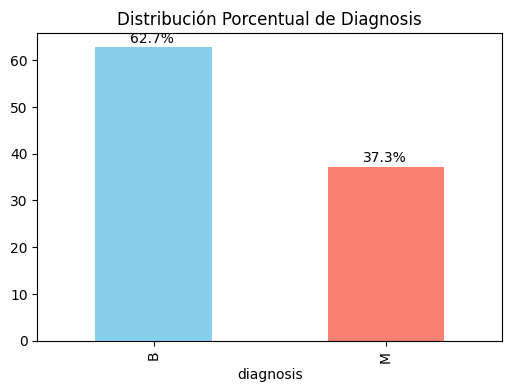

In [8]:
# Gráfico de barras porcentual
plt.figure(figsize=(6,4))
ax = (cancer_df['diagnosis'].value_counts(normalize=True) * 100).plot(kind='bar', color=['skyblue', 'salmon'])
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%', (p.get_x() + 0.15, p.get_height() + 1))
plt.title('Distribución Porcentual de Diagnosis')
plt.show()

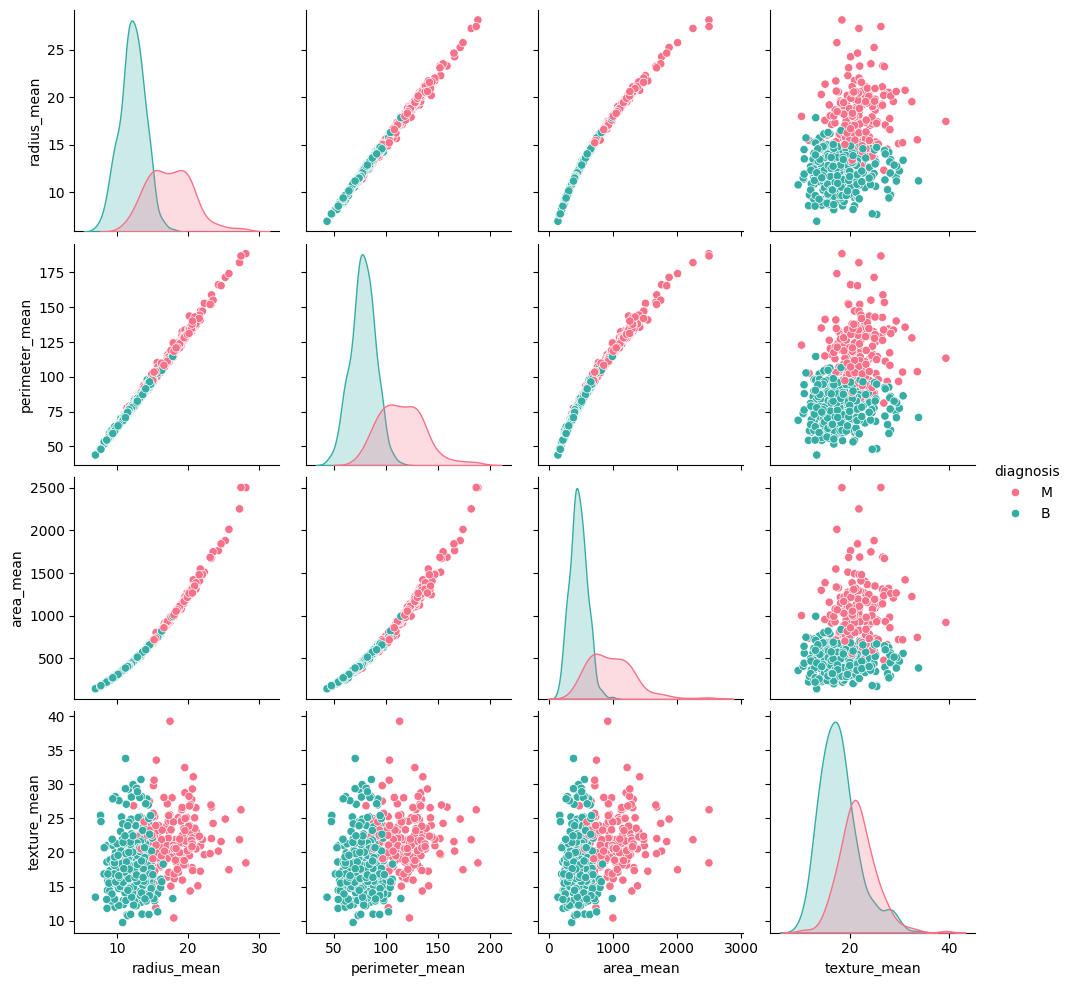

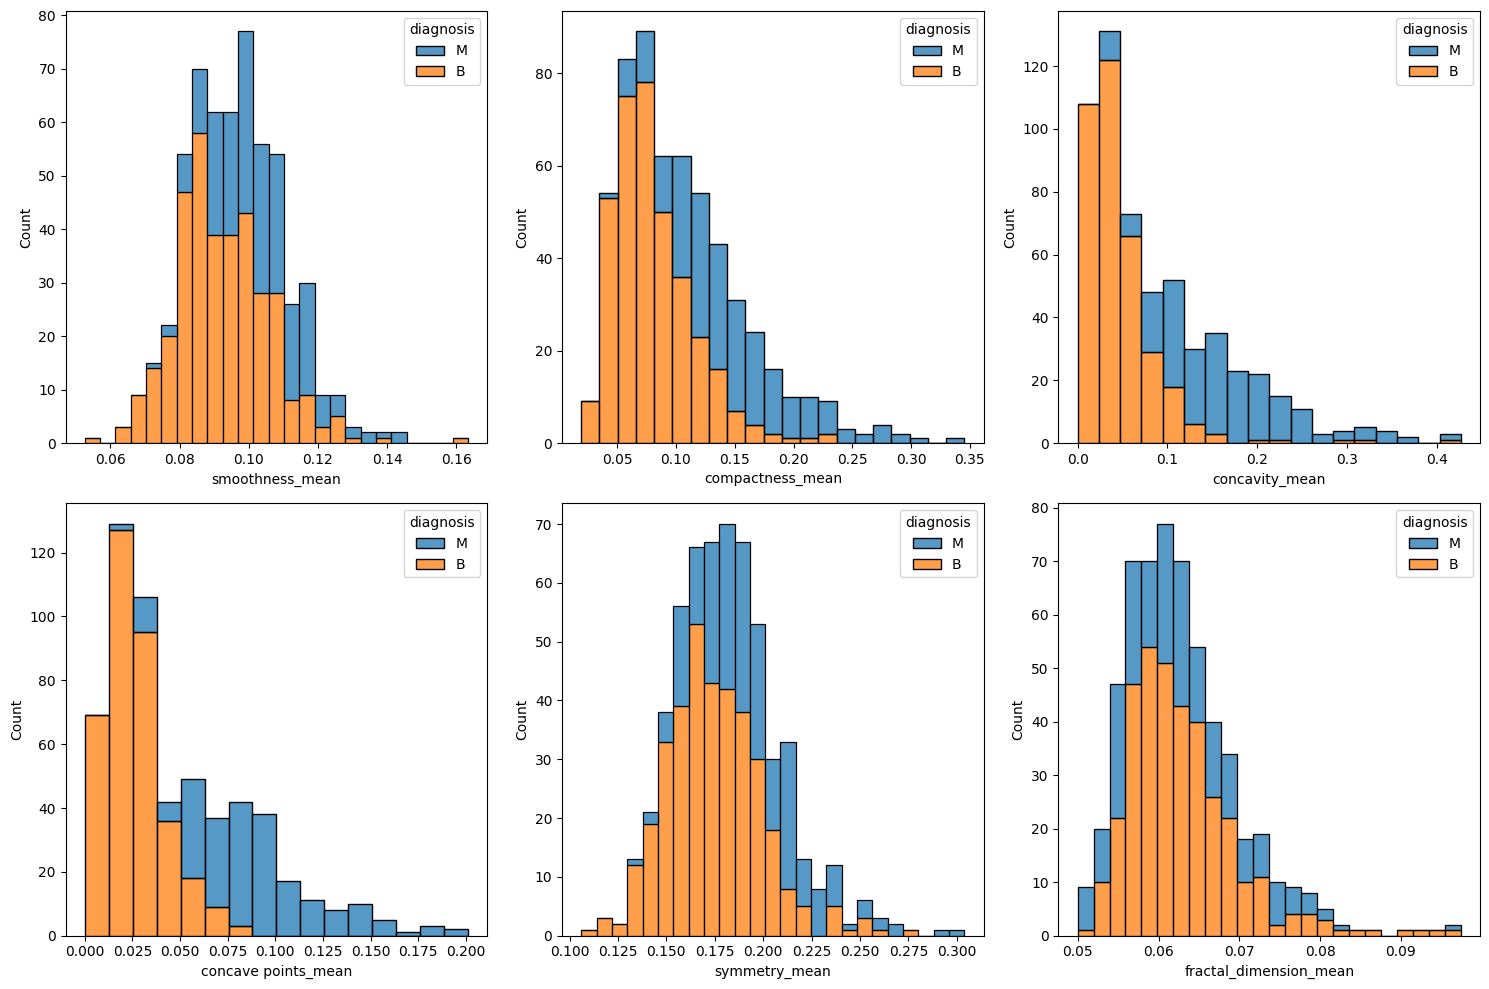

In [9]:
# Pairplot variables físicas (_mean)
fisicas = ['radius_mean', 'perimeter_mean', 'area_mean', 'texture_mean', 'diagnosis']
sns.pairplot(cancer_df[fisicas], hue='diagnosis', palette='husl')
plt.show()

# Histogramas apilados variables morfológicas
morfologicas = ['smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean']
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for i, col in enumerate(morfologicas):
    sns.histplot(data=cancer_df, x=col, hue='diagnosis', multiple="stack", ax=axes[i//3, i%3])
plt.tight_layout()
plt.show()

3. Antes de realizar el análisis de correlación, crea una copia del dataframe (`cancer_copy`).
* Identifica los pares de variables cuya correlación sea superior a 0.9 e imprímelos. La alta correlación entre las variables del conjunto _mean y _worst es inevitable, ya que las columnas _worst representan esencialmente los valores máximos de las mismas características medidas en _mean. Elimina las columnas _worst para simplificar el análisis.
* Imprime nuevamente los pares con correlación superior a 0.9. Como habías observado previamente, existen relaciones lineales entre `radius`, `perimeter` y `area`, por lo que era esperable encontrar altas correlaciones. De estas tres medidas, ¿cuál mantendrías y por qué? Elimina todas las variables de los otros dos conjuntos.
* Dibuja un mapa de calor con la matriz de correlación para identificar si prevalece alguna correlación relevante. Si eliminas alguna otra variable, justifica tu elección.

In [10]:
# Crear copia del dataframe
cancer_copy = cancer_df.copy()

# Calcular matriz de correlación (solo valores numéricos)
corr_matrix = cancer_copy.corr(numeric_only=True).abs()

# Seleccionar la parte superior de la matriz para evitar duplicados
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Identificar pares con correlación > 0.9
high_corr_pairs = [(column, row) for column in upper.columns for row in upper.index if upper.loc[row, column] > 0.9]

print("Pares con correlación superior a 0.9 (Inicial):")
for pair in high_corr_pairs:
    print(f"{pair[0]} - {pair[1]}: {upper.loc[pair[1], pair[0]]:.4f}")

Pares con correlación superior a 0.9 (Inicial):
perimeter_mean - radius_mean: 0.9979
area_mean - radius_mean: 0.9874
area_mean - perimeter_mean: 0.9865
concave points_mean - concavity_mean: 0.9214
perimeter_se - radius_se: 0.9728
area_se - radius_se: 0.9518
area_se - perimeter_se: 0.9377
radius_worst - radius_mean: 0.9695
radius_worst - perimeter_mean: 0.9695
radius_worst - area_mean: 0.9627
texture_worst - texture_mean: 0.9120
perimeter_worst - radius_mean: 0.9651
perimeter_worst - perimeter_mean: 0.9704
perimeter_worst - area_mean: 0.9591
perimeter_worst - radius_worst: 0.9937
area_worst - radius_mean: 0.9411
area_worst - perimeter_mean: 0.9415
area_worst - area_mean: 0.9592
area_worst - radius_worst: 0.9840
area_worst - perimeter_worst: 0.9776
concave points_worst - concave points_mean: 0.9102


In [11]:
# Eliminar las columnas que contienen el sufijo _worst
cols_worst = [c for c in cancer_copy.columns if '_worst' in c]
cancer_copy.drop(columns=cols_worst, inplace=True)

# Volver a calcular e imprimir correlaciones > 0.9
corr_matrix_reduced = cancer_copy.corr(numeric_only=True).abs()
upper_reduced = corr_matrix_reduced.where(np.triu(np.ones(corr_matrix_reduced.shape), k=1).astype(bool))
high_corr_reduced = [(column, row) for column in upper_reduced.columns for row in upper_reduced.index if upper_reduced.loc[row, column] > 0.9]

print("\nPares con correlación superior a 0.9 (Después de eliminar _worst):")
for pair in high_corr_reduced:
    print(f"{pair[0]} - {pair[1]}: {upper_reduced.loc[pair[1], pair[0]]:.4f}")


Pares con correlación superior a 0.9 (Después de eliminar _worst):
perimeter_mean - radius_mean: 0.9979
area_mean - radius_mean: 0.9874
area_mean - perimeter_mean: 0.9865
concave points_mean - concavity_mean: 0.9214
perimeter_se - radius_se: 0.9728
area_se - radius_se: 0.9518
area_se - perimeter_se: 0.9377


Decisión: Mantendría area_mean.
Justificación: Aunque las tres variables están linealmente relacionadas, el área es una medida que escala de forma cuadrática respecto al radio y proporciona una representación más robusta del volumen o magnitud física del tumor en una imagen 2D. Al mantener area_mean, capturamos la información de tamaño necesaria, eliminando la redundancia matemática que aportan el radio y el perímetro.

4. Separa las variables predictoras `X` de la variable de salida `y`, usando el dataframe original `cancer_df` (la eliminación de variables correlacionadas se integrará en el pipeline).
* Codifica `diagnosis` como 0 (Benigno) y 1 (Maligno).
* Divide el conjunto de datos en entrenamiento y prueba (80:20), usando `random_state=1` para garantizar reproducibilidad.
* Para evaluar los modelos que se construirán, define una función llamada `evaluate_model` que reciba los valores reales y las predicciones e imprima las métricas de recall, precisión y exactitud (accuracy).

In [12]:
# Separar variables predictoras X de la variable de salida y
X = cancer_df.drop(columns=['diagnosis'])

# Codificar diagnosis: 0 para Benigno (B) y 1 para Maligno (M)
y = cancer_df['diagnosis'].map({'B': 0, 'M': 1})

# Verificación rápida de la codificación
print("Conteo de clases en 'y':")
print(y.value_counts())

Conteo de clases en 'y':
diagnosis
0    357
1    212
Name: count, dtype: int64


In [13]:


# División 80% entrenamiento y 20% prueba con random_state=1
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=1)

print(f"Tamaño del conjunto de entrenamiento: {X_train.shape[0]} registros")
print(f"Tamaño del conjunto de prueba: {X_test.shape[0]} registros")

Tamaño del conjunto de entrenamiento: 455 registros
Tamaño del conjunto de prueba: 114 registros


In [14]:
from sklearn.metrics import recall_score, precision_score, accuracy_score

def evaluate_model(y_real, y_pred):
    """
    Calcula e imprime las métricas de Recall, Precisión y Accuracy.
    """
    recall = recall_score(y_real, y_pred)
    precision = precision_score(y_real, y_pred)
    accuracy = accuracy_score(y_real, y_pred)

    print(f"Recall:    {recall:.4f}")
    print(f"Precisión: {precision:.4f}")
    print(f"Exactitud: {accuracy:.4f}")

    return [recall, precision, accuracy]

5. Prepara un transformador denominado `preprocessing`, usando ColumnTransformer, para borrar las columnas altamente correlacionadas (identificadas en el ejercicio 3) Asegúrate de incluir el parámetro `remainder='passthrough'` para mantener el resto de las variables.
* Crea un pipeline que integre el transformador y regresión logística para  entrenar un modelo.
* Evalúa el desempeño del modelo en el conjunto de prueba empleando la función `evaluate_model`.
* Integra los resultados en un dataframe que contenga el nombre del modelo (*Correlation_Clean*) y una columna para cada métrica calculada.

In [15]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline  # Aseguramos la importación con P mayúscula
from sklearn.linear_model import LogisticRegression

# Lista de columnas a eliminar (identificadas en el ejercicio 3)
cols_to_drop = [c for c in X.columns if '_worst' in c] + ['radius_mean', 'perimeter_mean']

# Prepara el transformador para borrar las columnas correlacionadas
preprocessing = ColumnTransformer(
    transformers=[
        ('drop_corr', 'drop', cols_to_drop)
    ],
    remainder='passthrough'
)

# Crea el Pipeline que integra el transformador y la regresión logística
# Nota: Debe ser Pipeline con "P" mayúscula
pipe_corr = Pipeline(steps=[
    ('pre', preprocessing),
    ('clf', LogisticRegression(max_iter=10000))
])

# Entrenar el modelo
pipe_corr.fit(X_train, y_train)

# Evaluar el desempeño
print("Resultados para el modelo Correlation_Clean:")
metrics_clean = evaluate_model(y_test, pipe_corr.predict(X_test))

# Integra los resultados en un dataframe
results = pd.DataFrame(columns=['Recall', 'Precision', 'Accuracy'])
results.loc['Correlation_Clean'] = metrics_clean

# Mostrar resultados
results

Resultados para el modelo Correlation_Clean:
Recall:    0.7619
Precisión: 0.9143
Exactitud: 0.8860


,Recall,Precision,Accuracy
Correlation_Clean,0.761905,0.914286,0.885965


6. Una alternativa para reducir la multicolinealidad es el análisis de componentes principales. Construye un pipeline que incluya escalado estándar, PCA y regresión logística, manteniendo el número mínimo de componentes principales que expliquen al menos el 90% de la varianza.
* Entrena el modelo utilizando el conjunto de entrenamiento y evalúalo en el conjunto de prueba.
* Añade los valores de las métricas obtenidas al dataframe de resultados, utilizando como nombre del modelo *Standard_PCA*.
* ¿Cuántos componentes principales se emplearon?

In [16]:
# Crear el pipeline: Escalado -> PCA (90% varianza) -> Regresión Logística
pipe_pca = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.90)),
    ('clf', LogisticRegression())
])

# Entrenar el modelo
pipe_pca.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()), ('pca', PCA(n_components=0.9)),
                ('clf', LogisticRegression())])

In [17]:
# Evaluar el desempeño en el conjunto de prueba
print("Métricas para el modelo Standard_PCA:")
metrics_pca = evaluate_model(y_test, pipe_pca.predict(X_test))

# Añadir al dataframe de resultados
results.loc['Standard_PCA'] = metrics_pca

# Mostrar resultados actualizados
print("\nTabla de resultados:")
print(results)

Métricas para el modelo Standard_PCA:
Recall:    0.9286
Precisión: 1.0000
Exactitud: 0.9737

Tabla de resultados:
                     Recall  Precision  Accuracy
Correlation_Clean  0.761905   0.914286  0.885965
Standard_PCA       0.928571   1.000000  0.973684


In [18]:
# Obtener el número de componentes empleados
n_components = pipe_pca.named_steps['pca'].n_components_
print(f"\n¿Cuántos componentes principales se emplearon? {n_components}")


¿Cuántos componentes principales se emplearon? 7


7. Como intento de mejorar las métricas del modelo, y dado que todas las variables presentan sesgo, aplica una normalización utilizando Yeo-Johnson. Para ello:
* Crea un pipeline que integre el transformador `preprocessing`, una transformación Yeo-Johnson y regresión logística.
* Entrena el modelo utilizando el conjunto de entrenamiento y evalúalo en el conjunto de prueba.
* Añade los valores de las métricas obtenidas al dataframe de resultados, utilizando como nombre del modelo *Correlation_Yeo*.

In [19]:
# Crear el pipeline:
# 1. Preprocessing (borra columnas)
# 2. Yeo-Johnson (normaliza/estabiliza varianza)
# 3. Regresión Logística
pipe_yeo = Pipeline(steps=[
    ('pre', preprocessing),
    ('yeo', PowerTransformer(method='yeo-johnson')),
    ('clf', LogisticRegression())
])

# Entrenar el modelo
pipe_yeo.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('pre',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('drop_corr', 'drop',
                                                  ['radius_worst',
                                                   'texture_worst',
                                                   'perimeter_worst',
                                                   'area_worst',
                                                   'smoothness_worst',
                                                   'compactness_worst',
                                                   'concavity_worst',
                                                   'concave points_worst',
                                                   'symmetry_worst',
                                                   'fractal_dimension_worst',
                                                   'radius_mean',
                                                   'perimeter_mean'])])),
                ('yeo', PowerTransformer()), ('clf', LogisticRegression())])

In [20]:
# Evaluar el desempeño en el conjunto de prueba
print("Métricas para el modelo Correlation_Yeo:")
metrics_yeo = evaluate_model(y_test, pipe_yeo.predict(X_test))

# Añadir al dataframe de resultados
results.loc['Correlation_Yeo'] = metrics_yeo

# Mostrar tabla final de resultados
print("\nTabla de resultados comparativa:")
print(results)

Métricas para el modelo Correlation_Yeo:
Recall:    0.9524
Precisión: 1.0000
Exactitud: 0.9825

Tabla de resultados comparativa:
                     Recall  Precision  Accuracy
Correlation_Clean  0.761905   0.914286  0.885965
Standard_PCA       0.928571   1.000000  0.973684
Correlation_Yeo    0.952381   1.000000  0.982456


8. Del modelo anterior, obtén los nombres de los predictores empleados. ¿Cuántos son?
* Revisa los coeficientes del modelo de regresión logística y analiza su magnitud para identificar las variables 10 más influyentes.
* Grafícalas en un barplot horizontal, mostrando el valor del coeficiente y respetando su signo.

In [21]:
# Obtener los nombres de las columnas que pasaron por el preprocesamiento
# El resto de variables que no están en cols_to_drop son las que se usaron
nombres_predictores = [col for col in X.columns if col not in cols_to_drop]

print(f"Nombres de los predictores empleados: {nombres_predictores}")
print(f"\n¿Cuántos son? {len(nombres_predictores)}")

Nombres de los predictores empleados: ['texture_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal_dimension_se']

¿Cuántos son? 18


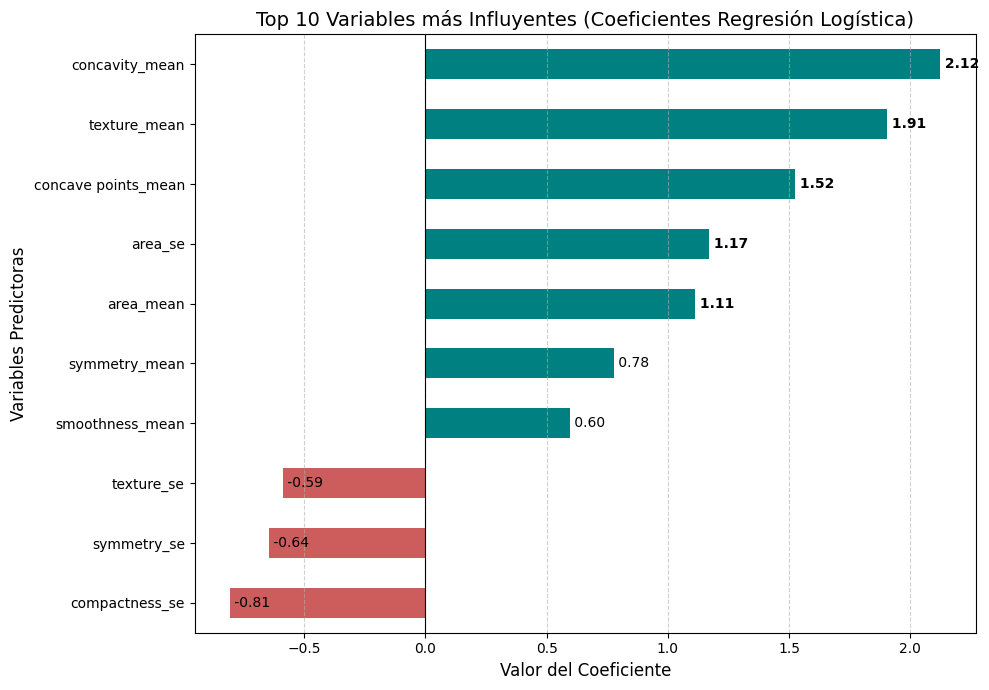

In [22]:
# Extraer coeficientes del modelo de regresión logística dentro del pipeline
coeficientes = pipe_yeo.named_steps['clf'].coef_[0]

# Crear una Serie de pandas para facilitar el manejo
import pandas as pd
import matplotlib.pyplot as plt

coef_df = pd.Series(coeficientes, index=nombres_predictores)

# Identificar las 10 variables más influyentes (basado en valor absoluto)
# pero manteniendo su signo para el gráfico
top_10 = coef_df.reindex(coef_df.abs().sort_values(ascending=False).index).head(10)

# Ordenarlas para que el gráfico sea estético (de menor a mayor impacto)
top_10 = top_10.sort_values()

# Graficar barplot horizontal
plt.figure(figsize=(10, 7))
colores = ['indianred' if x < 0 else 'teal' for x in top_10]
ax = top_10.plot(kind='barh', color=colores)

# Mostrar el valor del coeficiente al final de la barra
for i, v in enumerate(top_10):
    ax.text(v, i, f' {v:.2f}', va='center', fontweight='bold' if abs(v) > 1 else 'normal')

plt.axvline(0, color='black', linewidth=0.8) # Línea en el eje cero
plt.title('Top 10 Variables más Influyentes (Coeficientes Regresión Logística)', fontsize=14)
plt.xlabel('Valor del Coeficiente', fontsize=12)
plt.ylabel('Variables Predictoras', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

9. Imprime el dataframe de resultados.
* Dibuja la matriz de confusión del mejor modelo. ¿Qué significa cada valor en ella?
* Dibuja la curva ROC del mismo modelo y describe lo que indica sobre su capacidad para distinguir entre clases.

In [27]:
# Imprimir el dataframe que consolida las métricas de los tres modelos
print("Resumen de métricas por modelo:")
results

Resumen de métricas por modelo:


,Recall,Precision,Accuracy
Correlation_Clean,0.761905,0.914286,0.885965
Standard_PCA,0.928571,1.000000,0.973684
Correlation_Yeo,0.952381,1.000000,0.982456


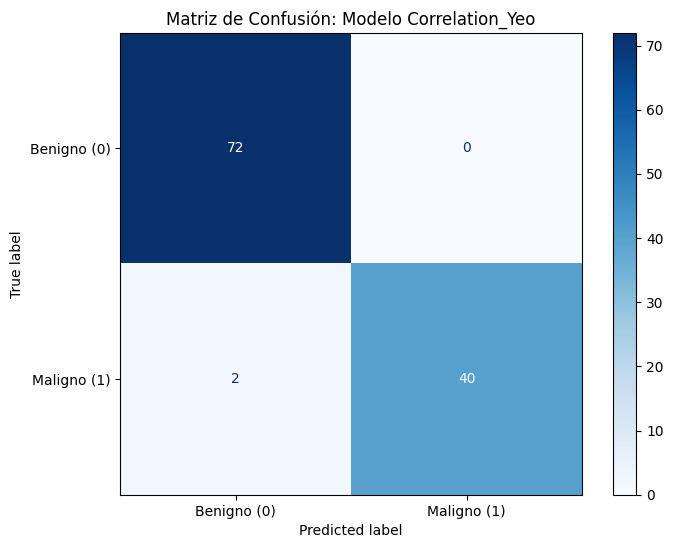

In [28]:
from sklearn.metrics import ConfusionMatrixDisplay

# Dibujar la matriz de confusión para el modelo pipe_yeo
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_estimator(pipe_yeo, X_test, y_test,
                                      display_labels=['Benigno (0)', 'Maligno (1)'],
                                      cmap='Blues', ax=ax)
plt.title('Matriz de Confusión: Modelo Correlation_Yeo')
plt.show()

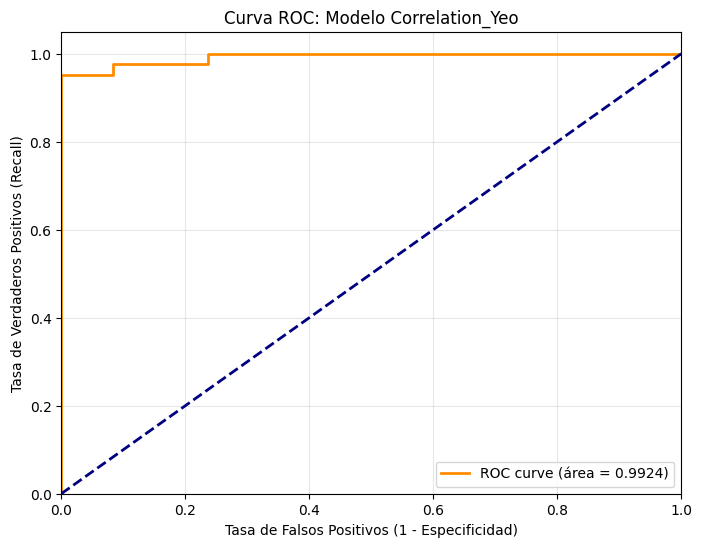

In [29]:


from sklearn.metrics import roc_curve, auc

# Obtener las probabilidades de la clase positiva (1)
y_probs = pipe_yeo.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

# Graficar la curva ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (área = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (1 - Especificidad)')
plt.ylabel('Tasa de Verdaderos Positivos (Recall)')
plt.title('Curva ROC: Modelo Correlation_Yeo')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

10. Grafica la distribución de las probabilidades predichas por clase utilizando histogramas superpuestos, diferenciando la clase Benigno (B) y la clase Maligno (M) con colores.
* ¿Cuál es el umbral (*threshold*) por defecto que utiliza scikit-learn para convertir probabilidades en predicciones binarias?
* En un modelo de diagnóstico médico, ¿cuál consideras que es la métrica más importante?
* ¿Cómo cambiarías (disminuir / aumentar) el *threshold*? ¿Por qué?

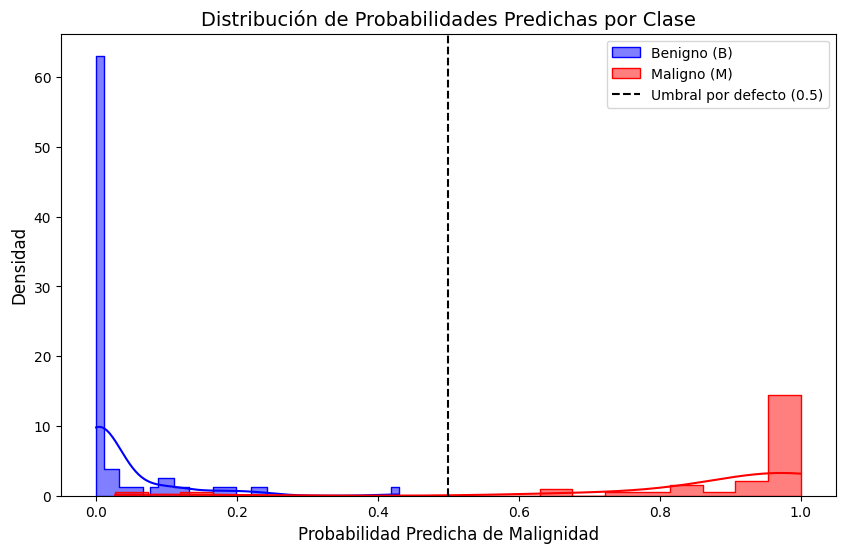

In [30]:
# Obtener las probabilidades de la clase Maligno (1) para el conjunto de prueba
y_probs = pipe_yeo.predict_proba(X_test)[:, 1]

plt.figure(figsize=(10, 6))

# Histograma para la clase Benigna (0)
sns.histplot(y_probs[y_test == 0], color="blue", label="Benigno (B)",
             kde=True, stat="density", alpha=0.5, element="step")

# Histograma para la clase Maligna (1)
sns.histplot(y_probs[y_test == 1], color="red", label="Maligno (M)",
             kde=True, stat="density", alpha=0.5, element="step")

# Línea del umbral por defecto (0.5)
plt.axvline(0.5, color='black', linestyle='--', label='Umbral por defecto (0.5)')

plt.title('Distribución de Probabilidades Predichas por Clase', fontsize=14)
plt.xlabel('Probabilidad Predicha de Malignidad', fontsize=12)
plt.ylabel('Densidad', fontsize=12)
plt.legend()
plt.show()